# Watch Calibration Experiment

The watch calibration experiment serves as an extremely basic example of how to record data, analyze it, and make your experiment completely reproducible for others far into the future. The concept of and code for this experiment is rather simple, and the focus is instead on best practices for archiving data, code, and the environment that runs the code.

## jupyter notebook

This jupyter notebook serves as a development environment

## imports and setup

In [1]:
# automatically reload watch_calibration python package in case we edit it
%load_ext autoreload
%autoreload 2
# enable the ipympl backend for interactive figures
%matplotlib widget

import copy
import os
import time 

import ipywidgets as widgets
import librosa
import numpy as np
import random
import scipy
from ipympl.backend_nbagg import Canvas
from matplotlib import pyplot as plt
from scipy import signal as sps
from scipy.io.wavfile import write

# globally remove ipympl headers
Canvas.header_visible.default_value = False

# import watch calibration experiment code
from watch_calibration import WatchCalibration

In [2]:
# set environment variables
RAW_DATA_PATH = os.environ["ARTS_RAW_DATA_PATH"]

In [3]:
# prevent race condition where plots aren't showing after "Restart Kernel and Run All Cells" is selected
time.sleep(.5)

# suppress warning about too many open figures
plt.rcParams.update({'figure.max_open_warning': 0})

In [4]:
# close all open plots to free up memory
plt.close('all')

## raw data collection/generation

In [5]:
# show all system audio inputs and outputs
WatchCalibration.query_devices()

  0 MacBook Pro Microphone, Core Audio (1 in, 0 out)
< 1 MacBook Pro Speakers, Core Audio (0 in, 2 out)
> 2 0_full, Core Audio (4 in, 4 out)
  3 ZoomAudioDevice, Core Audio (2 in, 2 out)


In [6]:
# audio recording parameters

# use system defaults; can change to int values above corresponding to specific interfaces
INPUT_DEVICE = None
OUTPUT_DEVICE = None

data_names = [
    "W241130",
    "250227",
    "250227_5m"
]
data_name = data_names[1]

In [7]:
# instantiate experiment code class
wc = WatchCalibration(data_name)

In [8]:
def recreate_dataset(generate=True, duration=60):
    """Create new data set from scratch.
        generate
        duration
    """

    wc.save_audio_to_file(duration, input_device=INPUT_DEVICE, generate=generate)

# Uncomment the next line to record duration seconds of audio 
# recreate_dataset(generate=False, duration=5*60)

# play audio file
# Uncomment the next line to play the selected audio file
# wc.play_audio(audio_file, output_device=OUTPUT_DEVICE)

## data visualization

In [9]:
watch_audio, fs = wc.load_audio()

### plot time and frequency signal

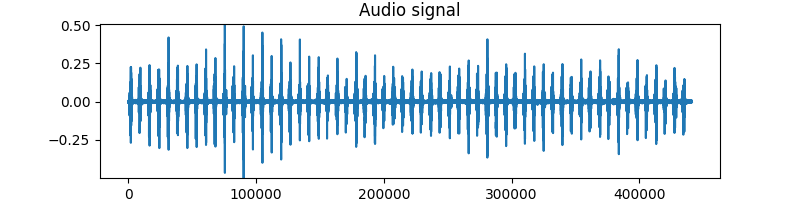

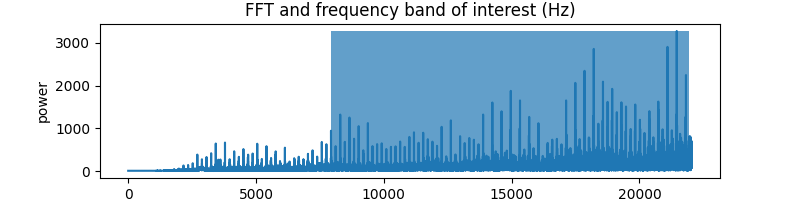

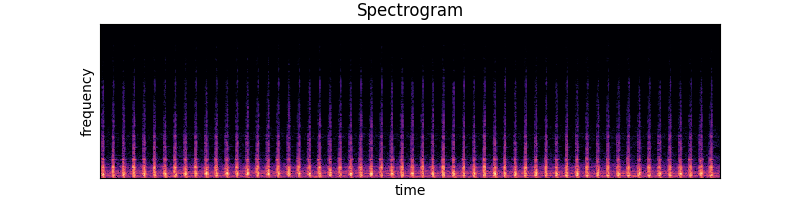

In [10]:
PLT_SECS = 10 

# plot last PLT_SECS seconds of time signal and spectrogram; plot full fft 
wc.plot_audio(watch_audio, plt_secs=PLT_SECS)

## derivative data

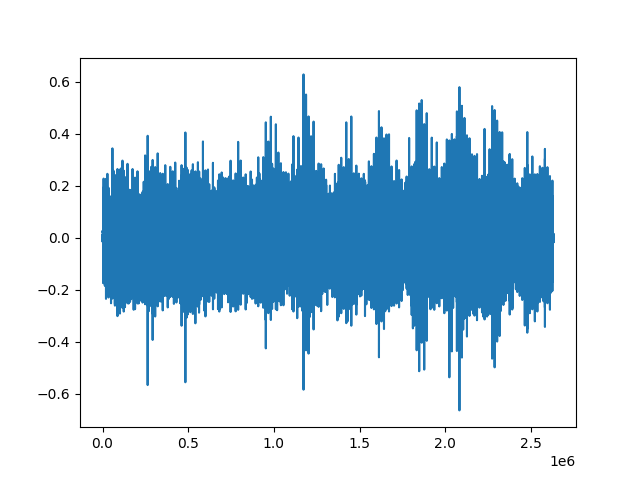

2631300


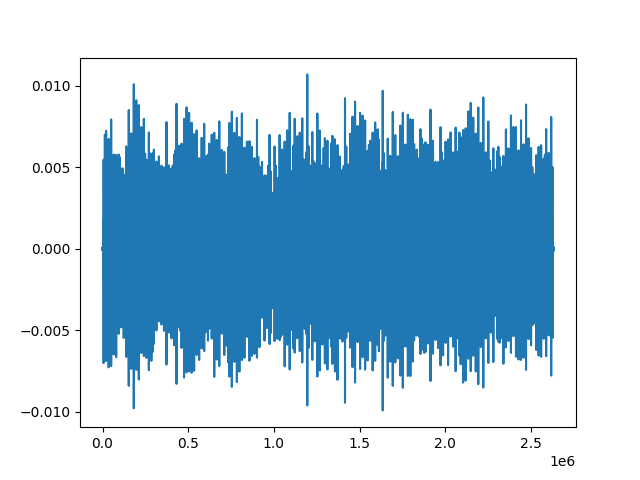

In [11]:
deriv_data = wc.create_deriv_from_raw(filter=True)
# deriv_data = wc.create_deriv_from_raw(watch_audio)
wc.save_deriv_data()

## Analysis

### Background

The goal of this analysis is to determine the clock drift of the watch measured in the supplied audio recording. By clock drift here, we mean the amount per unit time that recorded watch ticks will differ from those from an ideal clock with an invariant tick frequency. In order to calculate clock drift, we first need to precisely and accurately determine the time at which watch ticks occur.

There a number of ways to pick out clock ticks from an audio waveform, but the basic idea is to pinpoint where all the clock ticks happen by looking at the waveform and where it peaks in amplitude, calculate the average time between clicks in the recording, and compare it to the ideal tick period. This assumes that the clock ticks are ideally tuned to a specific frequency (in this case, 6 Hz) which comprise a 1 Hz rythym defining a second.

### Manual method

A fairly manual method to achieve a rough estimate of clock drift using Audacity can be found [here](https://www.instructables.com/Calibrate-a-Mechanical-Watch-Using-Sound-Waves/) and includes amplification of the signal, noise reduction, the generation of an ideal click track, alignment of the intial peaks, and measurement of the timing difference between final peaks. Once the difference is measured, the clock drift is simply the difference divided by the unit time over which the drift is measured. This method requires visually aligning signal peaks and realistically can measure drift on the order of a few milliseconds per recording at best.

### Automated method

To automate this, we make use of the `scipy.signal.find_peaks` and `numpy.correlate` functions. 

This method is implemeted by the `WatchCalibration.perform_analysis` method which calls ...

```
find_peaks
block out sets
make sure there is a window for each one
cross correlation
hilbert transform
re run across entire set
do stats

fit template to peak (template matching)
convex hull -> hilbert transform
run a cross correlation
```


### find_peaks



FloatSlider(value=0.0, max=57.666666666666664)

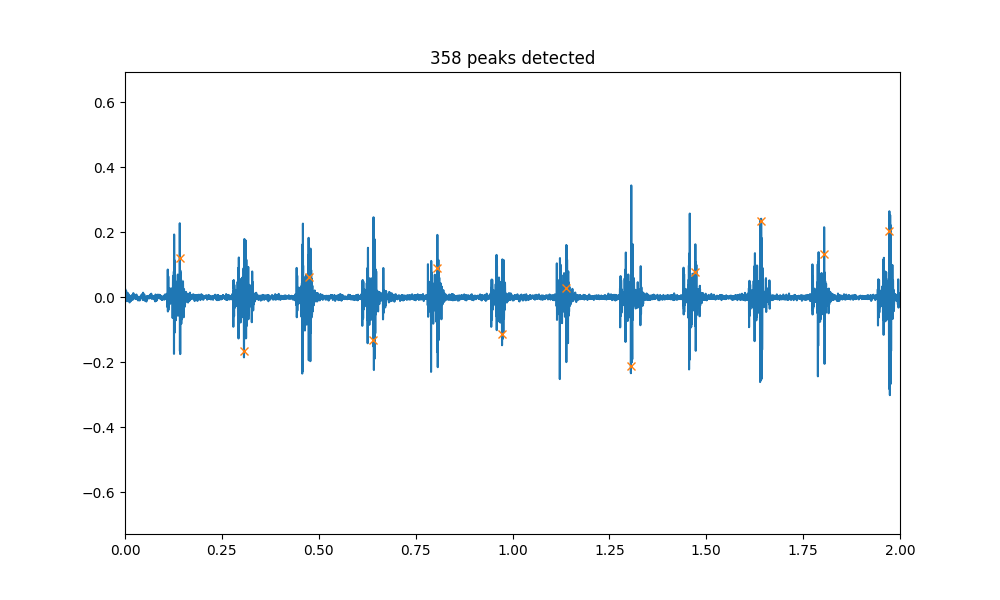

In [12]:
FREQ_GUESS = 6.
PEAK_PROMINENCE = 0.002


distance = int(wc.fs/FREQ_GUESS*.9)
win_size = int(wc.fs/FREQ_GUESS)
comp_audio = wc.trim_audio(watch_audio)
    
def plot_peaks(x, peaks):
    if len(x) > wc.fs * 2:
        fig, ax = plt.subplots(figsize=(10,6))
        t = np.arange(len(x))/wc.fs
        ax.plot(t, x)
        ax.plot(peaks/wc.fs, x[peaks], "x")
        ax.set_xlim(0,2)
        ax.set_title(f"{len(peaks)} peaks detected")
        
        slider = widgets.FloatSlider(value=0, max=len(x)/wc.fs-2, step=0.1, continuous_update=True)
        def update(change):
            ax.set_xlim(change.new, (change.new+2))
            fig.canvas.draw_idle() 
        slider.observe(update, names='value')
    
        display(slider)
    

# peaks = sps.find_peaks(comp_audio, distance=distance, prominence=PEAK_PROMINENCE, wlen=distance)[0]
# print(peaks)
# print(wc.peaks)
plot_peaks(comp_audio, wc.peaks)

### cross-correlation

Cross-correlation gives us a way to measure similarity between two signals. For digital signals, the dot product between the two signals is calculated repeatedly as the signals are shifted along the x-axis with respect to each other. The index of the maximum value of the cross-correlation result indicates by how many samples the signals should be shifted in order to be most aligned. 

We use this method to determine how much to shift the tick period between subsequent ticks as initially determined by the `find_peaks` method.

Below is a demonstration of how tick windows are aligned:

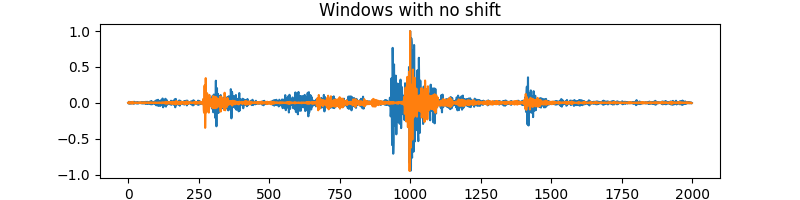

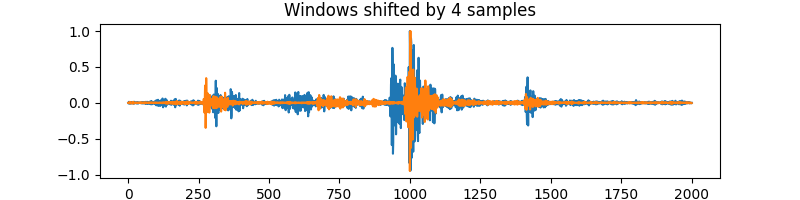

In [13]:
# pick two random tick windows
win1 = random.choice(wc.audio_wins)
win2 = random.choice(wc.audio_wins)

# normalize the windows
win1 = wc._normalize(win1)
win2 = wc._normalize(win2)

# determine the shift between the windows
shift = wc._corr_wins(win1, win2)

# plot the original and shifted windows 
wc.plot_wins(win1, win2, title="Windows with no shift")
wc.plot_wins(win1, win2, shift_amt=shift, title=f"Windows shifted by {shift} samples")

### filtering

Filtering the signal before running `find_peaks` or `correlate` can remove noise from the audio recording and make for a more accurate comparison of the underlying clock tick.

Here we filter the signal using a Butterworth band-pass filter from 6000 Hz to 8500 Hz. 

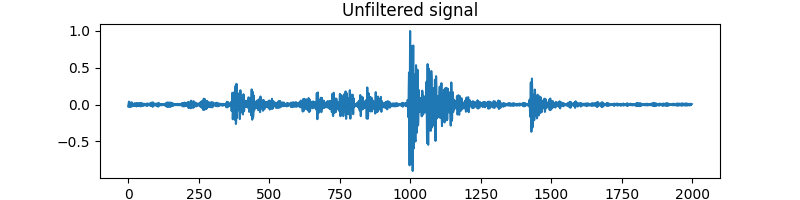

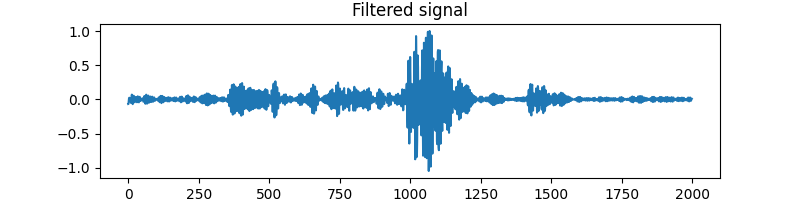

In [14]:
# remove first and last ticks from the signal
comp_audio = wc.trim_audio(watch_audio)

# filter out frequencies not in the specified band
freq_band = (6000, 8500)
filtered_audio = wc.filter_audio(comp_audio, freq_band=freq_band)

# pick random window to display
win_num = random.randrange(0, len(wc.audio_wins))
win = wc._normalize(wc.audio_wins[win_num])
peak = wc.peaks[win_num]
filt_win = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2])

# plot window and filtered version
wc.plot_wins(win, None, title="Unfiltered signal")
wc.plot_wins(filt_win, None, title="Filtered signal")

### envelope

We can also try to align tick windows based off their envelopes. The signal envelope is computed with `scipy.signal.envelope` and cross-correlation performed on the result.

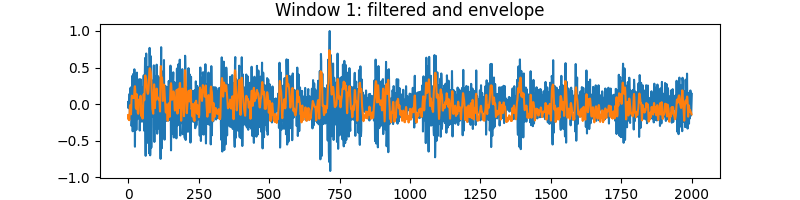

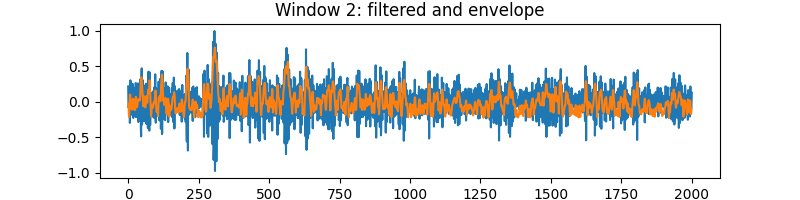

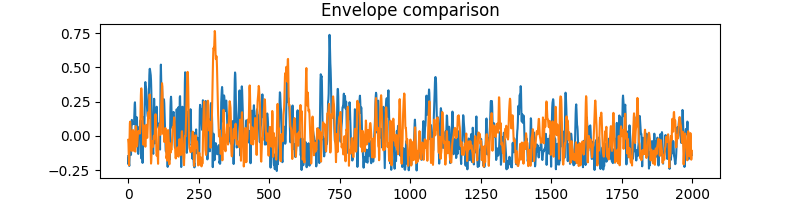

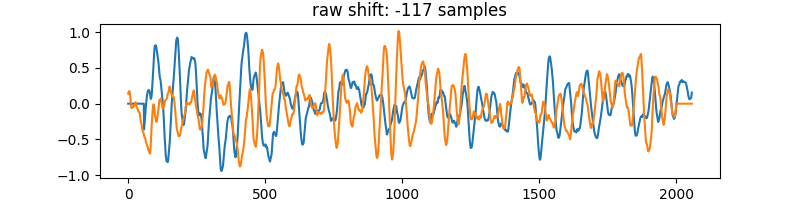

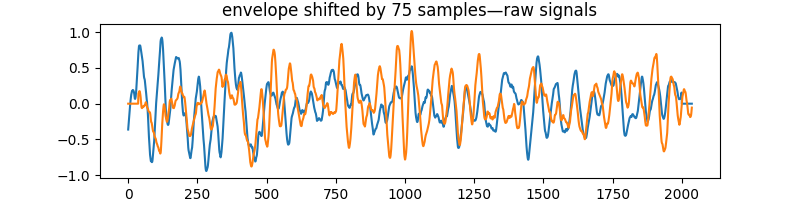

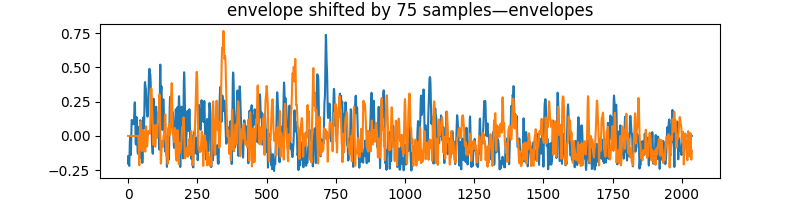

In [15]:
# show envelope example

comp_audio = watch_audio[wc.window_len:-wc.window_len]

filtered_audio, envelope = wc.calculate_envelope(comp_audio)

# pick random windows to display
win_num = random.randrange(0, len(wc.audio_wins))
peak = wc.peaks[win_num]
win1 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win1_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env1 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

win_num = random.randrange(0, len(wc.audio_wins))
peak = wc.peaks[win_num]
win2 = wc._normalize(comp_audio[peak-wc.window_len//2:peak+wc.window_len//2])
win2_filt = wc._normalize(filtered_audio[peak-wc.window_len//2:peak+wc.window_len//2 + 1])
env2 = wc._normalize(envelope[peak-wc.window_len//2:peak+wc.window_len//2])

wc.plot_wins(win1_filt, env1, title="Window 1: filtered and envelope")
wc.plot_wins(win2_filt, env2, title="Window 2: filtered and envelope")

wc.plot_wins(env1, env2, title="Envelope comparison")

shift_amt = wc._corr_wins(win1, win2)
wc.plot_wins(win1, win2, shift_amt, title=f"raw shift: {shift_amt} samples")
env_shift_amt = wc._corr_wins(env1, env2)
wc.plot_wins(win1, win2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—raw signals")
wc.plot_wins(env1, env2, env_shift_amt, title=f"envelope shifted by {env_shift_amt} samples—envelopes")

### comparison

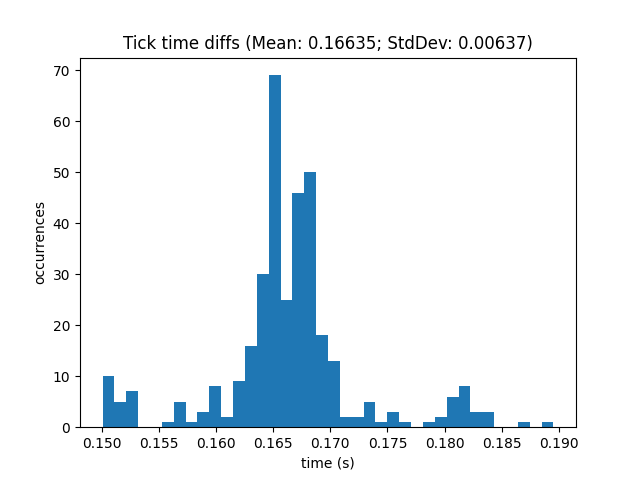

In [57]:
fig_wins = wc.view_correlations()
if fig_wins: display(fig_wins) 

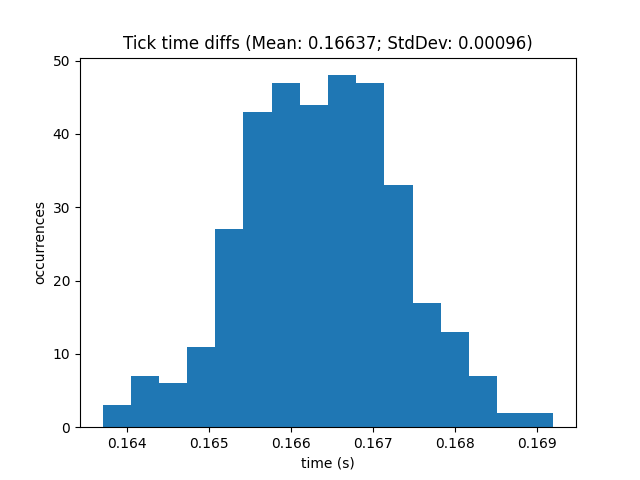

In [58]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True)
if fig_wins: display(fig_wins) 

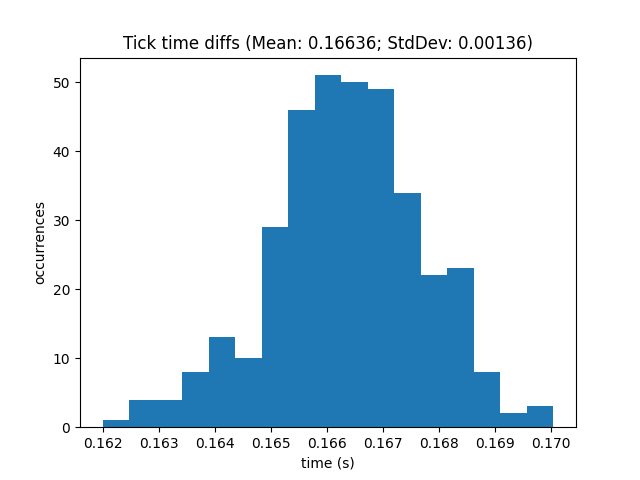

In [59]:
# cross-correlation shift
fig_wins = wc.view_correlations(filter=True, shift=True)
if fig_wins: display(fig_wins) 

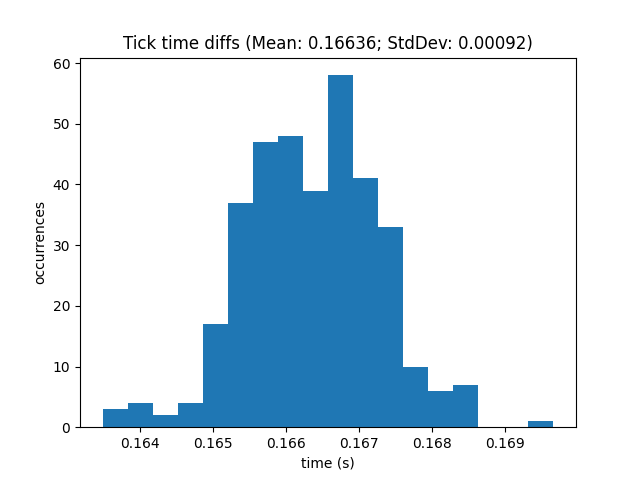

In [60]:
# cross-correlation shift on envelope
fig_wins = wc.view_correlations(filter=True, shift=True, envelope=True)
if fig_wins: display(fig_wins)

### Calculating drift

Now that we have a sense of the tick distribution for various sets of parameters, we calculate the drift for one of these sets. It seems that filtering, and shifting the peaks with an envelope consolidates the distribution. Interestingly, most of the distributions look bimodal, likely due to the fact that jitter (drift from window to window) in the positive direction in one window will correspond to negative jitter in the adjacent window.

#### Drift uncertainty

If the sampling rate fs is 44100, then the period (1/fs) is about 23 us. We don't have resolution beyond this, so the exact tick peak can fall anywhere in that 23 us window. In a 1 minute recording, the best we can do is tell if the drift from the first onset to the last onset is within 23 us (12.5 us of uncertainty on each onset). This represents an uncertainty in the drift calculation of 1.4 ms/h, 33 ms per day or about 1 s per month.

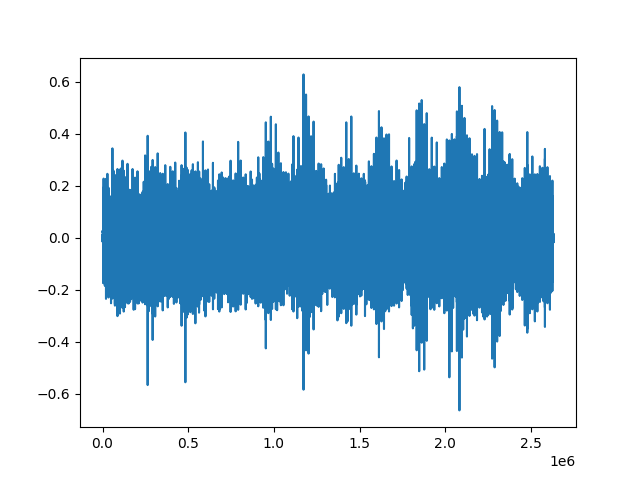

2631300


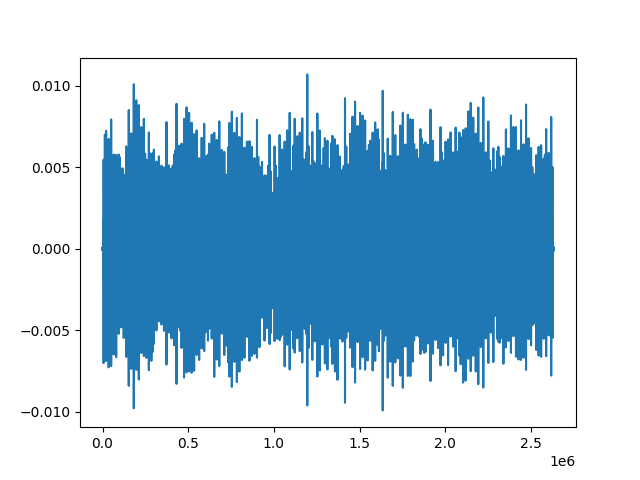

358
first tick time: 0.3072 s
actual last tick time: 59.3674
ideal last tick time: 59.4738
-0.10794 s drift in a minute
-6.48 s drift in a hour
-2.59 m drift in a day
-18.13 m drift in a week
-77.72 m drift in a month (30 days)
-945.55 m drift in a year (365 days)


In [20]:
drift_per_s = wc.perform_analysis(filter=True, envelope=True, shift=True)

### Calculate drift across all recordings and parameters

In [56]:
num_params = 3

res = np.zeros((len(data_names), *[num_params for i in range(num_params)]))

for i, d in enumerate(data_names):
    w = WatchCalibration(d)
    for j in range(2**num_params):
        filter = j%2
        envelope = (j>>1)%2
        shift = (j>>2)%2
        drift = w.perform_analysis(filter=filter, envelope=envelope, shift=shift, output=False)
        res[i, filter, envelope, shift] = drift

print(res)

[[[[ 9.35211268e-06  4.95774648e-06  0.00000000e+00]
   [ 1.27323944e-05  1.27323944e-05  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[-2.81690141e-06 -2.47887324e-06  0.00000000e+00]
   [ 9.01408451e-07  9.01408451e-07  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]]


 [[[-1.81776373e-03 -1.90629491e-03  0.00000000e+00]
   [-1.75031139e-03 -1.75031139e-03  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[-1.79706812e-03 -1.79476861e-03  0.00000000e+00]
   [-1.79898438e-03 -1.79898438e-03  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]]


 [[[-4.77516912e-05  1.9858639



### Generate figures for paper

In [ ]:
wc.generate_figures(watch_audio)